##### We have a problem with Delivery campaigns data which is the marketing company wants a strategy to make more money.
##### Task 1: Definining Exploratory Data Analysis with an overview of the whole project and also problem framing.
##### Task 2: Importing libraries and Exploring the Dataset.
##### Task 3: Check for missing values and data cleaning.
##### Task 4: Creating visual methods to analyze the data.
##### Task 5: Checking why there are a lot of inactive campains. 
##### Task 6: Do the same analysis but on not delivered campains. 
##### Task 7: Trying to see what is the optimal frequency, amount of money and cost per result. 

# Task 2: Importing libraries and Exploring the Dataset.

In [3]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from collections import Counter

In [4]:
campaignsData=pd.read_csv("dummy data.csv")

In [5]:
campaignsData.head()

,Campaign Delivery,Attribution setting,Results,Result indicator,Reach,Views,Frequency,Cost per results,Ad set budget,Ad set budget type,Amount spent (EGP),Ends,Impressions,"CPM (cost per 1,000 impressions) (EGP)",Link clicks,CPC (cost per link click) (EGP),CTR (link click-through rate),Clicks (all),CTR (all),CPC (all) (EGP)
0,NaN,Multiple attribution settings,NaN,NaN,3864172.0,NaN,6.635949,NaN,NaN,NaN,981715.13,NaN,25642447.0,38.284768,NaN,NaN,NaN,2052166.0,8.003004,0.478380
1,not_delivering,7-day click or 1-day view,136.0,actions:onsite_conversion.messaging_conversati...,9928.0,NaN,1.561644,4.612132,150,Daily,627.25,مستمرة,15504.0,40.457301,157.0,3.995223,1.012642,1797.0,11.590557,0.349054
2,not_delivering,-,NaN,NaN,NaN,NaN,NaN,NaN,1400,Lifetime,NaN,2024-01-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,completed,7-day click or 1-day view,104.0,actions:onsite_conversion.messaging_conversati...,19826.0,NaN,1.472965,13.461538,1400,Lifetime,1400.00,2024-01-22,29203.0,47.940280,200.0,7.000000,0.684861,790.0,2.705202,1.772152
4,inactive,7-day click or 1-day view,374.0,actions:onsite_conversion.messaging_conversati...,65744.0,NaN,2.395108,21.341043,150,Daily,7981.55,مستمرة,157464.0,50.688094,837.0,9.535902,0.531550,4891.0,3.106107,1.631885


In [6]:
# Explore data
cleanedData=campaignsData.drop(['Views','Attribution setting','Result indicator'],axis=1)
cleanedData.info()
cleanedData.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Campaign Delivery                       246 non-null    object 
 1   Results                                 86 non-null     float64
 2   Reach                                   87 non-null     float64
 3   Frequency                               87 non-null     float64
 4   Cost per results                        86 non-null     float64
 5   Ad set budget                           246 non-null    object 
 6   Ad set budget type                      219 non-null    object 
 7   Amount spent (EGP)                      87 non-null     float64
 8   Ends                                    246 non-null    object 
 9   Impressions                             87 non-null     float64
 10  CPM (cost per 1,000 impressions) (EGP)  87 non-null     float6

,Results,Reach,Frequency,Cost per results,Amount spent (EGP),Impressions,"CPM (cost per 1,000 impressions) (EGP)",Link clicks,CPC (cost per link click) (EGP),CTR (link click-through rate),Clicks (all),CTR (all),CPC (all) (EGP)
count,86.000000,8.700000e+01,87.000000,86.000000,87.000000,8.700000e+01,87.000000,86.000000,86.000000,86.000000,8.700000e+01,87.000000,87.000000
mean,1089.872093,1.459546e+05,2.338835,20.473461,22568.163908,5.894815e+05,43.664259,3734.918605,7.153774,1.099743,4.717623e+04,6.615086,0.908860
std,1886.297256,4.184064e+05,0.902513,22.253531,105269.178228,2.747577e+06,17.969326,5648.613706,8.706062,0.704132,2.225533e+05,3.868687,0.578641
min,2.000000,1.900000e+02,1.094737,0.049557,5.530000,2.080000e+02,8.984981,2.000000,0.697188,0.095315,3.200000e+01,1.826965,0.058212
25%,130.750000,2.067550e+04,1.672992,7.416389,1410.970000,3.999800e+04,30.774162,231.250000,2.176548,0.479552,1.785500e+03,4.174202,0.470228
50%,417.500000,6.696300e+04,2.253602,17.166114,6102.360000,1.406430e+05,45.913682,1380.500000,4.339939,0.970971,8.319000e+03,5.585233,0.883462
75%,1127.000000,1.443500e+05,2.578996,24.713679,14356.910000,3.969380e+05,55.346856,3876.750000,9.219694,1.526312,2.527800e+04,7.200037,1.259937
max,10394.000000,3.864172e+06,6.635949,176.784000,981715.130000,2.564245e+07,93.539719,28735.000000,67.993846,2.966185,2.052166e+06,20.365558,2.705413


# Task 3: Check for missing values and data cleaning.

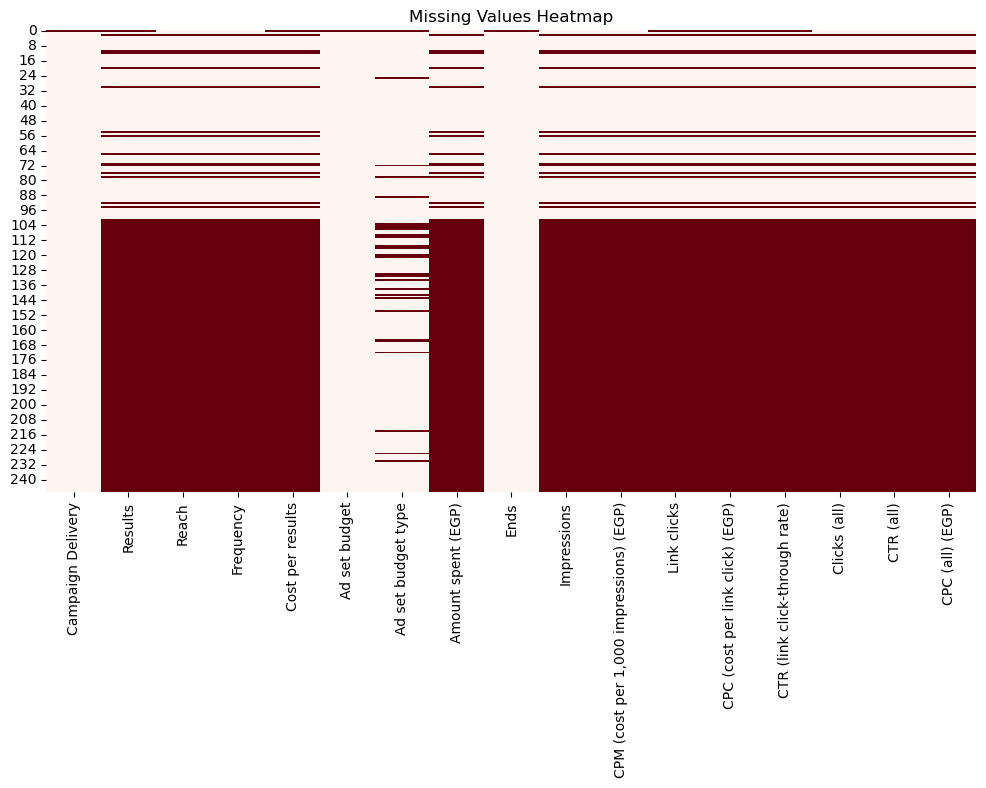

In [8]:
# Heatmap for missing values (if any)
plt.figure(figsize=(12, 6))
sns.heatmap(cleanedData.isnull(), cbar=False, cmap="Reds")
plt.title("Missing Values Heatmap")
plt.show()

There is a lot of missing data and need to be cleaned.

In [10]:
# Replace arabic word with active word
cleanedData['Ends'] = cleanedData['Ends'].replace('مستمرة', 'Active')

I need to replace and arabic word with english word.

In [12]:
# Dropping NAN values because it will not be important in our anlysis.
cleanedData=cleanedData.dropna(thresh=15)

In [13]:
cleanedData

,Campaign Delivery,Results,Reach,Frequency,Cost per results,Ad set budget,Ad set budget type,Amount spent (EGP),Ends,Impressions,"CPM (cost per 1,000 impressions) (EGP)",Link clicks,CPC (cost per link click) (EGP),CTR (link click-through rate),Clicks (all),CTR (all),CPC (all) (EGP)
1,not_delivering,136.0,9928.0,1.561644,4.612132,150,Daily,627.25,Active,15504.0,40.457301,157.0,3.995223,1.012642,1797.0,11.590557,0.349054
3,completed,104.0,19826.0,1.472965,13.461538,1400,Lifetime,1400.00,2024-01-22,29203.0,47.940280,200.0,7.000000,0.684861,790.0,2.705202,1.772152
4,inactive,374.0,65744.0,2.395108,21.341043,150,Daily,7981.55,Active,157464.0,50.688094,837.0,9.535902,0.531550,4891.0,3.106107,1.631885
5,inactive,276.0,66963.0,2.414318,27.307029,150,Daily,7536.74,Active,161670.0,46.618049,589.0,12.795823,0.364322,5333.0,3.298695,1.413227
6,inactive,662.0,121771.0,2.584170,19.386571,200,Daily,12833.91,Active,314677.0,40.784392,1508.0,8.510550,0.479222,25089.0,7.972937,0.511535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,inactive,2602.0,200084.0,2.173207,2.357633,500,Daily,6134.56,Active,434824.0,14.108145,5550.0,1.105326,1.276378,70269.0,16.160332,0.087301
97,inactive,9883.0,525011.0,4.100000,3.034003,550,Daily,29985.05,Active,2152545.0,13.930046,21320.0,1.406428,0.990455,314647.0,14.617441,0.095297
98,inactive,1593.0,304102.0,2.804753,18.662938,750,Daily,29730.06,Active,852931.0,34.856348,16488.0,1.803133,1.933099,56811.0,6.660679,0.523315
99,inactive,1216.0,130034.0,3.082571,21.501324,1200,Daily,26145.61,Active,400839.0,65.227211,3531.0,7.404591,0.880902,23283.0,5.808567,1.122949


# Task 4: Creating visual methods to analyze the data.

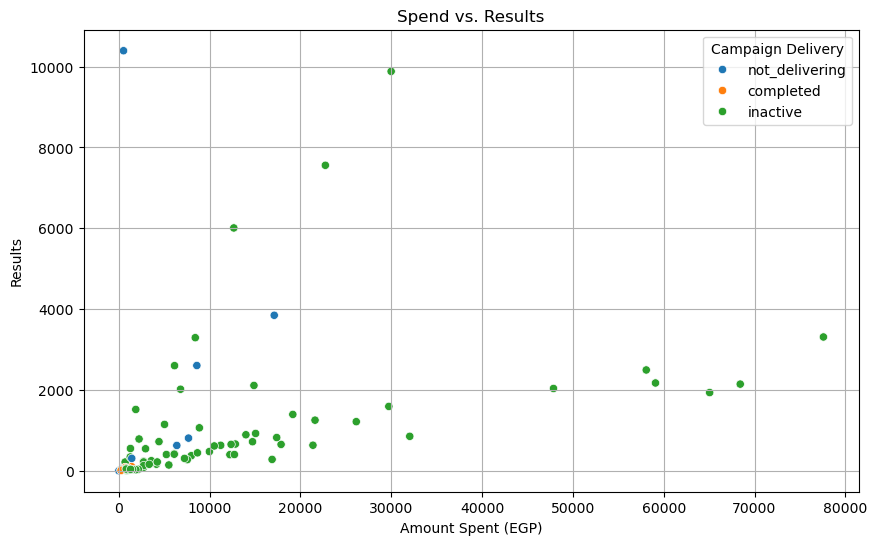

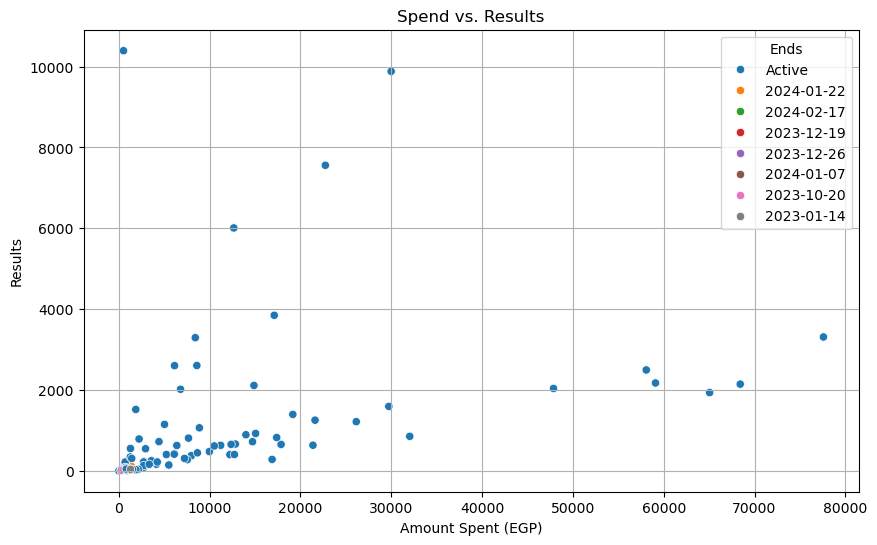

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleanedData, x="Amount spent (EGP)", y="Results", hue="Campaign Delivery")
plt.title("Spend vs. Results")
plt.xlabel("Amount Spent (EGP)")
plt.ylabel("Results")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleanedData, x="Amount spent (EGP)", y="Results", hue="Ends")
plt.title("Spend vs. Results")
plt.xlabel("Amount Spent (EGP)")
plt.ylabel("Results")
plt.grid(True)
plt.show()

From this two plot you are spending more monet if low result inactive campains and also from the second graph this inactive campains are paused not deleted so my first impression you should spend more money on the high result campaigns.

# Task 5: Checking why there are a lot of inactive campains.

In [18]:
#Splitting the assumed reasons for inactivity.
inactive_df = cleanedData[cleanedData['Campaign Delivery'] == 'inactive'].copy()
def reason_for_inactivity(row):
    reasons = []
    if row['Reach'] < 50000:
        reasons.append("Low reach")
    if row['Impressions'] < 1000:
        reasons.append("Low impressions")
    if row['CTR (all)'] < 1.0:
        reasons.append("Low CTR")
    if pd.notna(row['CPC (cost per link click) (EGP)']) and row['CPC (cost per link click) (EGP)'] > 10:
        reasons.append("High CPC")
    if pd.notna(row['Frequency']) > 3.5 or pd.notna(row['Frequency']) < 2.3:
        reasons.append("Bad frquency")    
    return ', '.join(reasons)

inactive_df['Inactive Reason'] = inactive_df.apply(reason_for_inactivity, axis=1)

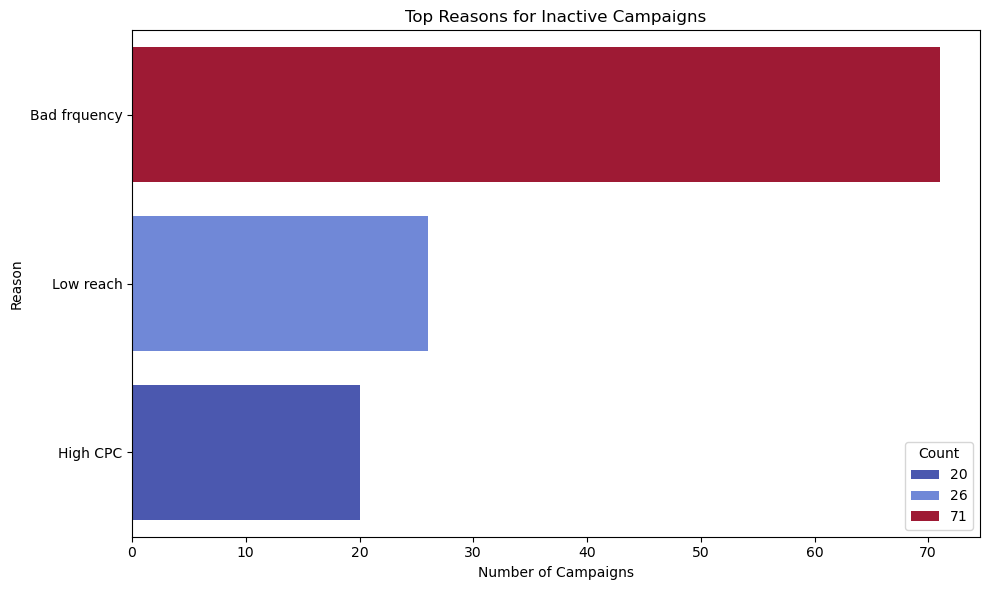

In [19]:
# Trying to get the top reasons for inactivity
reason_counts = Counter(
    reason for sublist in inactive_df['Inactive Reason'].str.split(', ') for reason in sublist if reason
)
reason_df = pd.DataFrame(reason_counts.items(), columns=['Reason', 'Count']).sort_values(by='Count', ascending=False)
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Count', y='Reason', data=reason_df, palette='coolwarm',hue='Count')
plt.title("Top Reasons for Inactive Campaigns")
plt.xlabel("Number of Campaigns")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

Form this plot there is a problem with frequncy and this can be the reason why the campaign is inactive. 

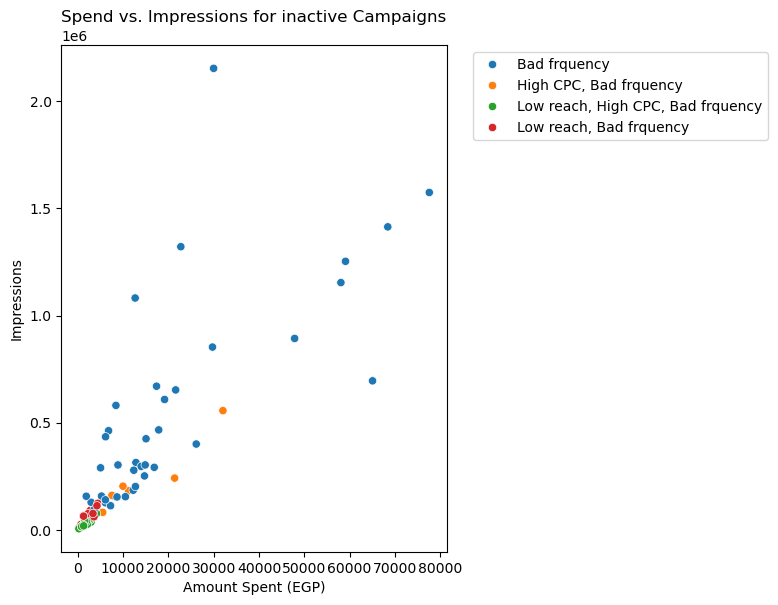

In [21]:
# Trying to see if there is a waste of money
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=inactive_df, 
    x='Amount spent (EGP)', 
    y='Impressions', 
    hue='Inactive Reason', 
    palette='tab10'
)
plt.title("Spend vs. Impressions for inactive Campaigns")
plt.xlabel("Amount Spent (EGP)")
plt.ylabel("Impressions")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This plot ensure that bad frequence cause a lot of damage on impressions and this causeed to lose money and pause the campaign

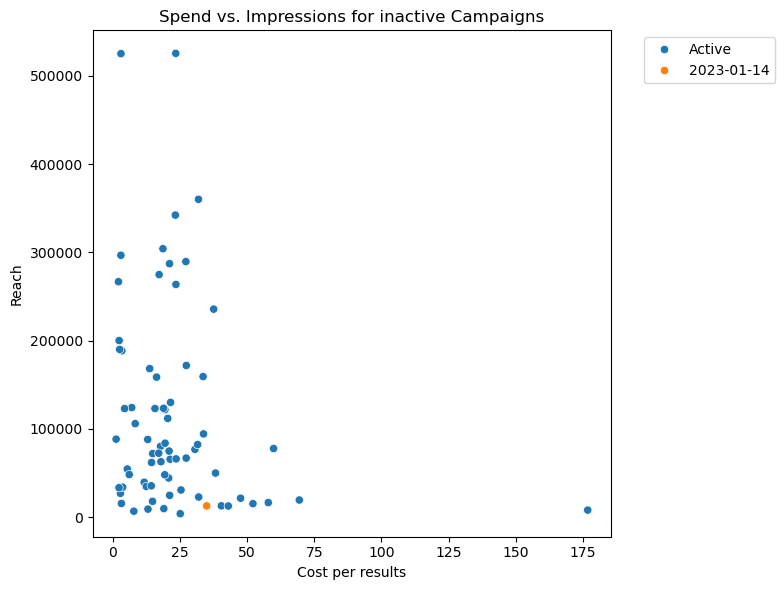

In [50]:
# Trying to get more money
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=inactive_df, 
    x='Cost per results', 
    y='Reach', 
    hue='Ends', 
    palette='tab10'
)
plt.title("Spend vs. Impressions for inactive Campaigns")
plt.xlabel("Cost per results")
plt.ylabel("Reach")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Among this plot there are a lot of active campaigns that has low cost per result and high reach so you should continue spending on them and fix the frequency problem and you will get more money.

# Task 6: Do the same analysis but on not delivered campains. 

In [68]:
#Splitting the assumed reasons for not completed.
not_delivering_df = cleanedData[cleanedData['Campaign Delivery'] == 'not_delivering'].copy()
def reason_for_not_delivering(row):
    reasons = []
    if row['Reach'] < 50000:
        reasons.append("Low reach")
    if row['Impressions'] < 1000:
        reasons.append("Low impressions")
    if row['CTR (all)'] < 1.0:
        reasons.append("Low CTR")
    if pd.notna(row['CPC (cost per link click) (EGP)']) and row['CPC (cost per link click) (EGP)'] > 10:
        reasons.append("High CPC")
    if pd.notna(row['Frequency']) > 3.5 or pd.notna(row['Frequency']) < 2.3:
        reasons.append("Bad frquency")    
    return ', '.join(reasons)

not_delivering_df['not_delivering Reason'] = not_delivering_df.apply(reason_for_not_delivering, axis=1)

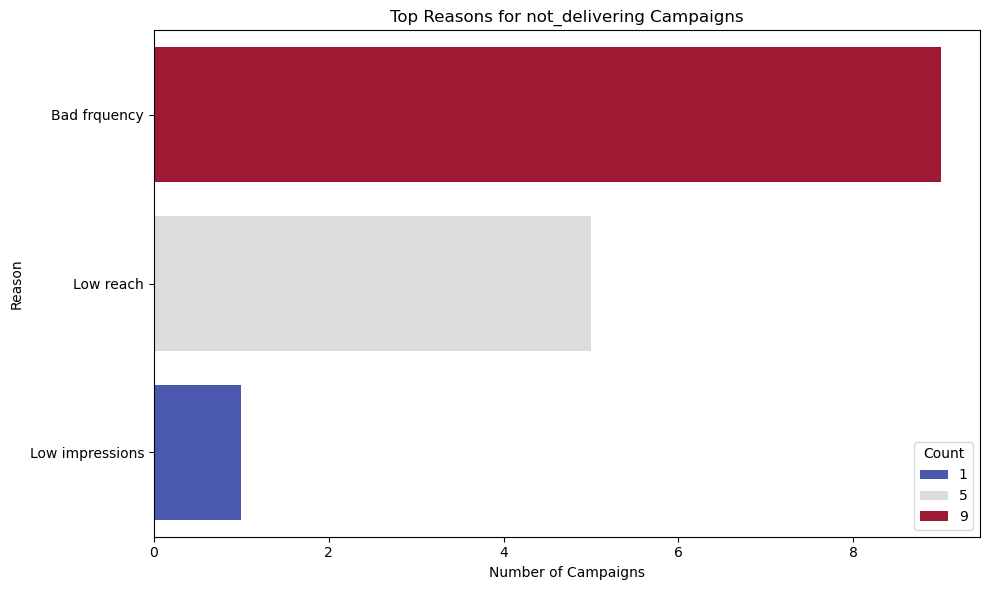

In [66]:
# Trying to get the top reasons for not completed
reason_counts = Counter(
    reason for sublist in not_delivering_df['not_delivering Reason'].str.split(', ') for reason in sublist if reason
)
reason_df = pd.DataFrame(reason_counts.items(), columns=['Reason', 'Count']).sort_values(by='Count', ascending=False)
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Count', y='Reason', data=reason_df, palette='coolwarm',hue='Count')
plt.title("Top Reasons for not_delivering Campaigns")
plt.xlabel("Number of Campaigns")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

Same problem as Inactive but now low reach is a problem too.

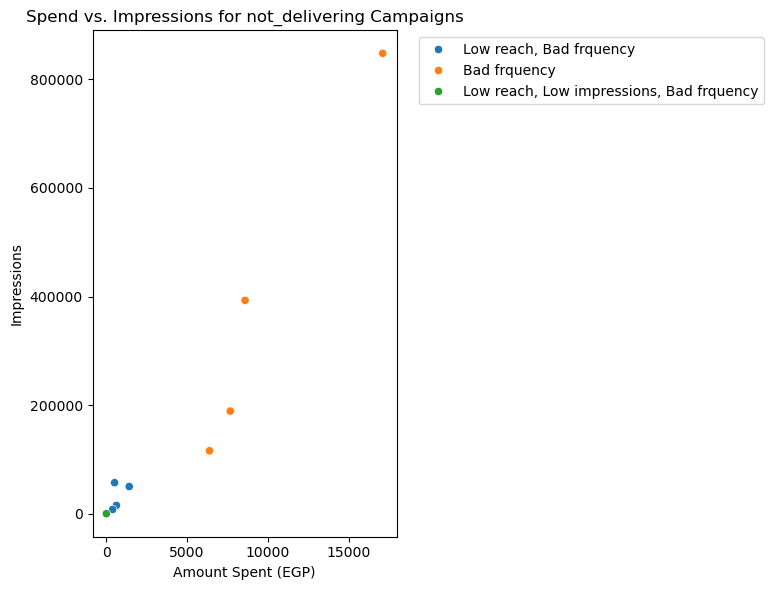

In [57]:
# Trying to see if there is a waste of money
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=not_delivering_df, 
    x='Amount spent (EGP)', 
    y='Impressions', 
    hue='not_delivering Reason', 
    palette='tab10'
)
plt.title("Spend vs. Impressions for not_delivering Campaigns")
plt.xlabel("Amount Spent (EGP)")
plt.ylabel("Impressions")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Throw this plots the problem was low reach and bad frequency so you wasted money on this campaigns.

# Task 7: Trying to see what is the optimal frequency, amount of money and cost per result. 

In [78]:
# See why completed campaigns was good.
completed_df = cleanedData[cleanedData['Campaign Delivery'] == 'completed'].copy()

In [96]:
completed_df['Performance Score'] = (
    (completed_df['Results'] / (completed_df['Amount spent (EGP)'])) * 
    completed_df['CTR (all)']
)
top_completed = completed_df.sort_values(by='Performance Score', ascending=False)
top_completed[['Campaign Delivery', 'Frequency','Cost per results', 'Results', 'Amount spent (EGP)', 'CTR (all)', 'CPC (cost per link click) (EGP)', 'Performance Score']].head(10)

,Campaign Delivery,Frequency,Cost per results,Results,Amount spent (EGP),CTR (all),CPC (cost per link click) (EGP),Performance Score
36,completed,1.548603,8.433735,83.0,700.00,5.057064,2.671756,0.599623
46,completed,1.534067,8.641111,81.0,699.93,3.823448,3.138700,0.442472
42,completed,1.623109,12.500000,56.0,700.00,4.364508,3.196347,0.349161
65,completed,1.706076,22.727273,11.0,250.00,5.825511,5.208333,0.256322
3,completed,1.472965,13.461538,104.0,1400.00,2.705202,7.000000,0.200958
13,completed,1.561460,15.671642,67.0,1050.00,2.971746,4.666667,0.189626


From this scores the optimal frequency for completed campaigns was around 1.4 and 1.65 and cost per result was optimal.